In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
from collections import Counter
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

PROJECT_DIR = Path("..")
DK_PATH = PROJECT_DIR / "data" / "temp_data" / "parliament" / "roll_calls_translated.csv"
EP_DATA_DIR = PROJECT_DIR / "EP" / "EP-data"
EP_PERIODS = ["2009-2014", "2014-2019", "2019-2024", "2024-2029"]
OUT_DIR = PROJECT_DIR / "data" / "temp_data" / "embeddings"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [5]:
df_dk = pd.read_csv(DK_PATH)
df_dk = df_dk.dropna(subset=["sag_titel_en"]).copy()
df_dk["sag_titel_en"] = df_dk["sag_titel_en"].astype(str).str.strip()
df_dk = df_dk[df_dk["sag_titel_en"].str.len() > 0].reset_index(drop=True)

print(f"DK titles: {len(df_dk):,}")
print(df_dk[["afstemningid", "sag_titel", "sag_titel_en"]].head(3))

DK titles: 2,128
   afstemningid                                          sag_titel  \
0             2  Forslag til lov om ændring af virksomhedsskatt...   
1          1783  Forslag til lov om ændring af lov om afgift af...   
2          2267  Forslag til lov om ændring af lov om produktio...   

                                        sag_titel_en  
0  Proposal for a law amending the Corporate Tax ...  
1  Proposal for a law amending the Law on the tax...  
2  Proposal for a law amending the Law on Product...  


In [6]:
ep_frames = []
for period in EP_PERIODS:
    path = EP_DATA_DIR / period / "ep_votes.csv"
    if not path.exists():
        print(f"Missing: {path}")
        continue
    df = pd.read_csv(path)
    df["period"] = period
    if "is_main" in df.columns:
        before = len(df)
        df = df[df["is_main"] == True].copy()
        print(f"{period}: {before:,} → {len(df):,} (is_main=True)")
    else:
        print(f"{period}: {len(df):,} (no is_main column; keeping all)")
    ep_frames.append(df)

df_ep = pd.concat(ep_frames, ignore_index=True)
df_ep = df_ep.dropna(subset=["display_title"]).copy()
df_ep["display_title"] = df_ep["display_title"].astype(str).str.strip()
df_ep = df_ep[df_ep["display_title"].str.len() > 0].reset_index(drop=True)

print(f"EP titles: {len(df_ep):,}")
print(df_ep[["id", "period", "display_title"]].head(3))

2009-2014: 6,961 (no is_main column; keeping all)
2014-2019: 10,252 (no is_main column; keeping all)
2019-2024: 1,808 → 1,808 (is_main=True)
2024-2029: 614 → 614 (is_main=True)
EP titles: 19,634
   id     period                                      display_title
0   1  2009-2014  Election of the President of the European Comm...
1   2  2009-2014  Agreement EC/Mongolia on certain aspects of ai...
2   3  2009-2014  EC-China agreement: maritime transport operati...


In [7]:
# Combining the titles
texts = pd.concat([
    df_dk["sag_titel_en"],
    df_ep["display_title"]
], ignore_index=True)

# Labels:
# 0 = Danish Parliament
# 1 = European Parliament
labels = np.concatenate([
    np.zeros(len(df_dk), dtype=int),
    np.ones(len(df_ep), dtype=int)])

print(f"Total titles: {len(texts):,}")
print(f"DK: {np.sum(labels == 0):,}")
print(f"EP: {np.sum(labels == 1):,}")

X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels)

print(f"\nTrain: {len(X_train_text):,}")
print(f"Test:  {len(X_test_text):,}")

Total titles: 21,762
DK: 2,128
EP: 19,634

Train: 17,409
Test:  4,353


ngram_range=(1, 2) means we are considering both european, parliament and also european parliament as 2-word prhase

In [9]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"Train TF-IDF shape: {X_train_tfidf.shape}")
print(f"Test TF-IDF shape:  {X_test_tfidf.shape}")
print(f"Vocabulary size:    {len(tfidf.get_feature_names_out()):,}")

Train TF-IDF shape: (17409, 16759)
Test TF-IDF shape:  (4353, 16759)
Vocabulary size:    16,759


In [10]:
lr_tfidf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

lr_tfidf.fit(X_train_tfidf, y_train)

y_pred = lr_tfidf.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["DK", "EP"]
    )
)

Accuracy: 0.9998

              precision    recall  f1-score   support

          DK       1.00      1.00      1.00       426
          EP       1.00      1.00      1.00      3927

    accuracy                           1.00      4353
   macro avg       1.00      1.00      1.00      4353
weighted avg       1.00      1.00      1.00      4353



Confusion matrix:
[[ 426    0]
 [   1 3926]]


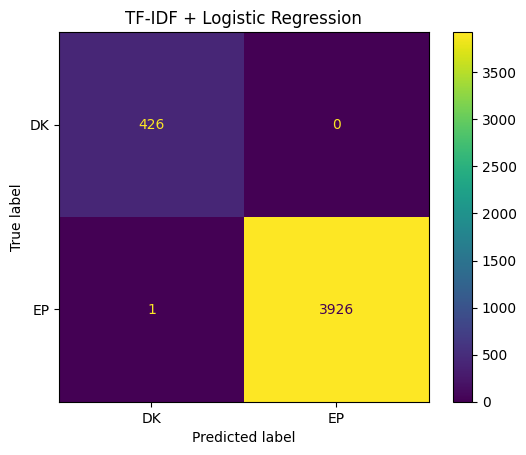

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["DK", "EP"]
)

disp.plot(values_format="d")
plt.title("TF-IDF + Logistic Regression")
plt.show()

In [11]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = lr_tfidf.coef_[0]

top_n = 30

# Negative coefficient = pushes prediction toward DK (0)
dk_idx = np.argsort(coefficients)[:top_n]

# Positive coefficient = pushes prediction toward EP (1)
ep_idx = np.argsort(coefficients)[-top_n:][::-1]


print("TOP TERMS PREDICTING DANISH PARLIAMENT")
print("=" * 60)

for idx in dk_idx:
    print(f"{feature_names[idx]:40s} {coefficients[idx]:8.3f}")


print("\nTOP TERMS PREDICTING EUROPEAN PARLIAMENT")
print("=" * 60)

for idx in ep_idx:
    print(f"{feature_names[idx]:40s} {coefficients[idx]:8.3f}")

TOP TERMS PREDICTING DANISH PARLIAMENT
law                                       -14.861
proposal for                               -8.069
law on                                     -8.045
proposal                                   -8.004
for law                                    -7.985
law amending                               -6.564
draft law                                  -6.543
amending the                               -6.476
act                                        -6.288
amending                                   -5.910
draft                                      -5.836
for                                        -5.342
on                                         -4.324
etc                                        -3.955
the                                        -3.755
the law                                    -3.387
suggested                                  -2.718
code                                       -2.124
tax                                        -2.013
of         

So the model isn't merely learning "Denmark" → DK. It appears to be learning a different style/structure of vote titles.
That's important for our embeddings... simply removing danish, denmark, european, EU, etc. probably won't be sufficient to eliminate source-specific separation.

In [13]:
top_n = 30

top_dk = pd.DataFrame({
    "term": feature_names[dk_idx],
    "coefficient": coefficients[dk_idx]
})

top_ep = pd.DataFrame({
    "term": feature_names[ep_idx],
    "coefficient": coefficients[ep_idx]
})

display(top_dk)
display(top_ep)

,term,coefficient
0,law,-14.860787
1,proposal for,-8.068962
2,law on,-8.044888
3,proposal,-8.003723
4,for law,-7.985250
5,law amending,-6.563560
6,draft law,-6.542689
7,amending the,-6.475533
8,act,-6.288089
9,amending,-5.910383


,term,coefficient
0,european,2.489532
1,eu,2.274225
2,budget,1.528264
3,report,1.411136
4,union,1.401884
5,the european,1.396580
6,the eu,1.335688
7,of the,1.326624
8,report on,1.052027
9,european union,0.942820


Trying to replace Denmark and EP with word "institition" 

In [14]:
import re

def normalize_institution_terms(text, source):
    text = str(text)

    if source == "DK":
        replacements = [
            (r"\bDanish Parliament\b", "institution"),
            (r"\bDenmark\b", "institution"),
            (r"\bDanish\b", "institutional"),
        ]

    elif source == "EP":
        replacements = [
            (r"\bEuropean Parliament\b", "institution"),
            (r"\bEuropean Union\b", "institution"),
            (r"\bEU\b", "institution"),
            (r"\bEuropean\b", "institutional"),
        ]

    for pattern, replacement in replacements:
        text = re.sub(
            pattern,
            replacement,
            text,
            flags=re.IGNORECASE
        )

    text = re.sub(r"\s+", " ", text).strip()

    return text


df_dk["title_normalized"] = df_dk["sag_titel_en"].apply(
    lambda x: normalize_institution_terms(x, "DK")
)

df_ep["title_normalized"] = df_ep["display_title"].apply(
    lambda x: normalize_institution_terms(x, "EP")
)

In [15]:
dk_changed = df_dk[
    df_dk["sag_titel_en"] != df_dk["title_normalized"]
]

ep_changed = df_ep[
    df_ep["display_title"] != df_ep["title_normalized"]
]

print(f"DK changed: {len(dk_changed):,} / {len(df_dk):,}")
print(f"EP changed: {len(ep_changed):,} / {len(df_ep):,}")

display(
    dk_changed[
        ["sag_titel_en", "title_normalized"]
    ].head(10)
)

display(
    ep_changed[
        ["display_title", "title_normalized"]
    ].head(10)
)

DK changed: 164 / 2,128
EP changed: 7,462 / 19,634


,sag_titel_en,title_normalized
3,Draft law on Danish tourism.,Draft law on institutional tourism.
9,Draft law on the Danish Green Investment Fund.,Draft law on the institutional Green Investmen...
13,Proposal for a law on the conclusion of the Pr...,Proposal for a law on the conclusion of the Pr...
14,Proposal for a law on the conclusion of the Pr...,Proposal for a law on the conclusion of the Pr...
41,Proposal for a law amending the Law on the con...,Proposal for a law amending the Law on the con...
42,Proposal for a law on the conclusion of a doub...,Proposal for a law on the conclusion of a doub...
48,Draft law amending the law on Danish citizensh...,Draft law amending the law on institutional ci...
69,Proposal for a law amending the law on plannin...,Proposal for a law amending the law on plannin...
84,Proposal for a law amending the VAT Act. (Impo...,Proposal for a law amending the VAT Act. (Impo...
90,Proposal for a law amending the Law on the Use...,Proposal for a law amending the Law on the Use...


,display_title,title_normalized
0,Election of the President of the European Comm...,Election of the President of the institutional...
3,Mobilisation of the European Globalisation Adj...,Mobilisation of the institutional Globalisatio...
4,Mobilisation of the European Union Solidarity ...,Mobilisation of the institution Solidarity Fund
5,Draft amending budget No 6/2009 on Draft amend...,Draft amending budget No 6/2009 on Draft amend...
6,Draft amending budget No 7/2009 on Draft amend...,Draft amending budget No 7/2009 on Draft amend...
7,Draft amending budget No 8/2009 \non Draft ame...,Draft amending budget No 8/2009 on Draft amend...
58,Report: Reimer Böge - Mobilisation of the EU S...,Report: Reimer Böge - Mobilisation of the inst...
65,Report: Herbert Reul- International Renewable ...,Report: Herbert Reul- International Renewable ...
69,Report: Lidia Joanna Geringer de Oedenberg - C...,Report: Lidia Joanna Geringer de Oedenberg - C...
70,Report: Lidia Joanna Geringer de Oedenberg - A...,Report: Lidia Joanna Geringer de Oedenberg - A...


In [16]:
texts_normalized = pd.concat([
    df_dk["title_normalized"],
    df_ep["title_normalized"]
], ignore_index=True)

# 0 = Danish Parliament
# 1 = European Parliament
labels_normalized = np.concatenate([
    np.zeros(len(df_dk), dtype=int),
    np.ones(len(df_ep), dtype=int)
])

print(f"Total titles: {len(texts_normalized):,}")
print(f"DK: {(labels_normalized == 0).sum():,}")
print(f"EP: {(labels_normalized == 1).sum():,}")

Total titles: 21,762
DK: 2,128
EP: 19,634


In [17]:
X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(
    texts_normalized,
    labels_normalized,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels_normalized
)

print(f"Train: {len(X_train_norm):,}")
print(f"Test:  {len(X_test_norm):,}")

Train: 17,409
Test:  4,353


In [18]:
tfidf_norm = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf_norm = tfidf_norm.fit_transform(X_train_norm)
X_test_tfidf_norm = tfidf_norm.transform(X_test_norm)

print(f"Train TF-IDF shape: {X_train_tfidf_norm.shape}")
print(f"Test TF-IDF shape:  {X_test_tfidf_norm.shape}")
print(f"Vocabulary size:    {len(tfidf_norm.get_feature_names_out()):,}")

Train TF-IDF shape: (17409, 16739)
Test TF-IDF shape:  (4353, 16739)
Vocabulary size:    16,739


In [19]:
lr_tfidf_norm = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

lr_tfidf_norm.fit(
    X_train_tfidf_norm,
    y_train_norm
)

y_pred_norm = lr_tfidf_norm.predict(
    X_test_tfidf_norm
)

print(f"Original accuracy:   {accuracy_score(y_test, y_pred):.4f}")
print(f"Normalized accuracy: {accuracy_score(y_test_norm, y_pred_norm):.4f}")

print("\nNORMALIZED TITLES")
print(
    classification_report(
        y_test_norm,
        y_pred_norm,
        target_names=["DK", "EP"]
    )
)

Original accuracy:   0.9998
Normalized accuracy: 0.9998

NORMALIZED TITLES
              precision    recall  f1-score   support

          DK       1.00      1.00      1.00       426
          EP       1.00      1.00      1.00      3927

    accuracy                           1.00      4353
   macro avg       1.00      1.00      1.00      4353
weighted avg       1.00      1.00      1.00      4353



[[ 426    0]
 [   1 3926]]


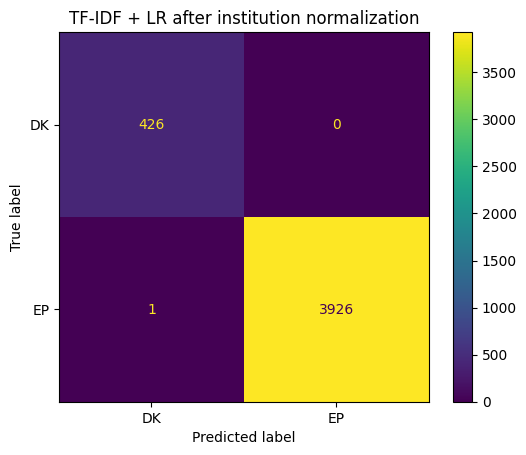

In [20]:
cm_norm = confusion_matrix(
    y_test_norm,
    y_pred_norm
)

print(cm_norm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["DK", "EP"]
)

disp.plot(values_format="d")
plt.title("TF-IDF + LR after institution normalization")
plt.show()

It didnt really help because the institution is many more times in EP and it became a new distinguisher is that okay since later on we use sentence translator or should we delete it? 

In [21]:
feature_names_norm = np.array(
    tfidf_norm.get_feature_names_out()
)

coefficients_norm = lr_tfidf_norm.coef_[0]

top_n = 30

dk_idx_norm = np.argsort(
    coefficients_norm
)[:top_n]

ep_idx_norm = np.argsort(
    coefficients_norm
)[-top_n:][::-1]

top_dk_norm = pd.DataFrame({
    "term": feature_names_norm[dk_idx_norm],
    "coefficient": coefficients_norm[dk_idx_norm]
})

top_ep_norm = pd.DataFrame({
    "term": feature_names_norm[ep_idx_norm],
    "coefficient": coefficients_norm[ep_idx_norm]
})

print("TOP DK TERMS AFTER NORMALIZATION")
display(top_dk_norm)

print("TOP EP TERMS AFTER NORMALIZATION")
display(top_ep_norm)

TOP DK TERMS AFTER NORMALIZATION


,term,coefficient
0,law,-14.915392
1,law on,-8.130922
2,proposal for,-8.082538
3,proposal,-8.018115
4,for law,-7.974989
5,draft law,-6.644371
6,law amending,-6.564321
7,amending the,-6.486697
8,act,-6.302639
9,amending,-5.921256


TOP EP TERMS AFTER NORMALIZATION


,term,coefficient
0,institution,2.957639
1,the institution,2.285787
2,budget,1.590762
3,report,1.424680
4,of the,1.424096
5,institutional,1.408833
6,report on,1.051267
7,discharge,0.941140
8,rule,0.912428
9,rule of,0.885252


Finding the most common beginnings of DK and EP titles

In [22]:
def common_prefixes(series, n_words, top_n=25):
    prefixes = []

    for text in series.dropna():
        words = str(text).lower().split()

        if len(words) >= n_words:
            prefixes.append(" ".join(words[:n_words]))

    return pd.DataFrame(
        Counter(prefixes).most_common(top_n),
        columns=["prefix", "count"]
    )

In [23]:
for n in [2, 3, 4, 5]:
    print(f"\n{'='*60}")
    print(f"EP — first {n} words")
    print("="*60)

    display(
        common_prefixes(
            df_ep["display_title"],
            n_words=n,
            top_n=20
        )
    )


EP — first 2 words


,prefix,count
0,motions for,528
1,implementation of,398
2,draft general,371
3,annual report,303
4,european semester,274
5,mobilisation of,223
6,decision on,203
7,preparation of,200
8,situation in,193
9,objection pursuant,190



EP — first 3 words


,prefix,count
0,motions for resolutions,528
1,draft general budget,371
2,implementation of the,367
3,european semester for,274
4,annual report on,251
5,mobilisation of the,211
6,decision on the,203
7,preparation of the,196
8,objection pursuant to,190
9,guidelines for the,186



EP — first 4 words


,prefix,count
0,motions for resolutions -,507
1,draft general budget of,371
2,european semester for economic,274
3,decision on the opening,202
4,objection pursuant to rule,190
5,general budget of the,181
6,preparation of the commission,173
7,mobilisation of the european,171
8,a 2030 framework for,149
9,motion for a resolution,125



EP — first 5 words


,prefix,count
0,draft general budget of the,371
1,european semester for economic policy,274
2,"decision on the opening of,",202
3,general budget of the european,181
4,preparation of the commission work,173
5,mobilisation of the european globalisation,156
6,a 2030 framework for climate,149
7,motion for a resolution -,123
8,estimates of revenue and expenditure,107
9,objection pursuant to rule 106:,105


In [24]:
# Inspecting the most common beginnings of Danish Parliament titles

for n in [2, 3, 4, 5]:
    print(f"\n{'='*60}")
    print(f"DK — first {n} words")
    print("="*60)

    display(
        common_prefixes(
            df_dk["sag_titel_en"],
            n_words=n,
            top_n=20
        )
    )


DK — first 2 words


,prefix,count
0,proposal for,1705
1,draft law,400
2,draft finance,10
3,draft tax,2
4,draft railway,1
5,draft address,1
6,suggested taxi,1
7,proposals for,1
8,suggested tattoo,1
9,suggested share-saving,1



DK — first 3 words


,prefix,count
0,proposal for a,1704
1,draft law amending,262
2,draft law on,130
3,draft finance act,10
4,draft law for,6
5,draft railway law.,1
6,draft address law.,1
7,proposal for the,1
8,draft tax control,1
9,draft tax reporting,1



DK — first 4 words


,prefix,count
0,proposal for a law,1702
1,draft law amending the,261
2,draft law on the,72
3,draft finance act for,10
4,draft law on additional,5
5,draft law on municipal,3
6,draft law for greenland,3
7,draft law for the,3
8,draft law on danish,2
9,draft law on a,2



DK — first 5 words


,prefix,count
0,proposal for a law amending,1492
1,proposal for a law on,172
2,draft law amending the law,168
3,draft law on the notification,19
4,proposal for a law supplementing,12
5,draft law amending the code,11
6,draft finance act for the,10
7,draft law amending the aliens,9
8,draft law amending the penal,9
9,draft law amending the criminal,9


This confirms that DK has an extremely strong template effect: 1,702 of our 2,128 DK titles begin with "Proposal for a law". That explains why LR can identify DK almost perfectly.

In [37]:
import re


# ============================================================
# CLEAN DANISH PARLIAMENT TITLES
# ============================================================

def clean_dk_title(text):
    text = str(text).strip()

    # Remove procedural framing at the START of DK titles
    procedural_patterns = [
        r"^proposal for a law amending\s+",
        r"^proposal for a law supplementing\s+",
        r"^proposal for a law repealing\s+",
        r"^proposal for a law prohibiting\s+",
        r"^proposal for a law on\s+",
        r"^proposal for a law\s+",

        r"^draft law amending\s+",
        r"^draft law on\s+",
        r"^draft law\s+",
    ]

    for pattern in procedural_patterns:
        new_text = re.sub(
            pattern,
            "",
            text,
            count=1,
            flags=re.IGNORECASE
        )

        if new_text != text:
            text = new_text
            break

    # Remove DK identifier only when it works as an adjective
    # Example:
    # "Danish energy policy" -> "energy policy"
    text = re.sub(
        r"\bDanish\s+(?=[A-Za-z])",
        "",
        text,
        flags=re.IGNORECASE
    )

    # Clean whitespace and punctuation
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s+([,.;:])", r"\1", text)
    text = text.strip(" -–—:,. ")

    return text


# ============================================================
# CLEAN EUROPEAN PARLIAMENT TITLES
# ============================================================

def clean_ep_title(text):
    text = str(text).strip()

    # --------------------------------------------------------
    # 1. Remove procedural framing at the START
    # --------------------------------------------------------

    procedural_patterns = [
        r"^motions for resolutions\s*[-–—:]\s*",
        r"^motions for resolutions\s+",

        r"^motion for a resolution\s*[-–—:]\s*",
        r"^motion for a resolution\s+",

        r"^annual report on\s+",
        r"^report on\s+",
    ]

    for pattern in procedural_patterns:
        new_text = re.sub(
            pattern,
            "",
            text,
            count=1,
            flags=re.IGNORECASE
        )

        if new_text != text:
            text = new_text
            break

    # --------------------------------------------------------
    # 2. Remove EU only when it occurs at the START
    #    as a simple institutional adjective
    # --------------------------------------------------------

    # Examples:
    # "EU strategy for..." -> "strategy for..."
    # "EU protein deficit" -> "protein deficit"
    # "EU trade negotiations..." -> "trade negotiations..."
    #
    # But:
    # "EU-UK relations" stays unchanged.
    text = re.sub(
        r"^EU\s+(?=[A-Za-z])",
        "",
        text,
        flags=re.IGNORECASE
    )

    # --------------------------------------------------------
    # 3. Clean whitespace and punctuation
    # --------------------------------------------------------

    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s+([,.;:])", r"\1", text)
    text = text.strip(" -–—:,. ")

    return text


# ============================================================
# CREATE CLEAN COLUMNS
# Original columns remain unchanged
# ============================================================

df_dk["title_clean"] = df_dk["sag_titel_en"].apply(clean_dk_title)

df_ep["title_clean"] = df_ep["display_title"].apply(clean_ep_title)


# ============================================================
# CHECK HOW MANY CHANGED
# ============================================================

dk_changed = df_dk[
    df_dk["sag_titel_en"] != df_dk["title_clean"]
]

ep_changed = df_ep[
    df_ep["display_title"] != df_ep["title_clean"]
]

print(
    f"DK changed: {len(dk_changed):,} / {len(df_dk):,} "
    f"({len(dk_changed) / len(df_dk):.1%})"
)

print(
    f"EP changed: {len(ep_changed):,} / {len(df_ep):,} "
    f"({len(ep_changed) / len(df_ep):.1%})"
)

DK changed: 2,128 / 2,128 (100.0%)
EP changed: 1,644 / 19,634 (8.4%)


In [38]:
dk_changed = df_dk[
    df_dk["sag_titel_en"] != df_dk["title_clean"]
]

ep_changed = df_ep[
    df_ep["display_title"] != df_ep["title_clean"]
]

print(
    f"DK changed: {len(dk_changed):,} / {len(df_dk):,} "
    f"({len(dk_changed) / len(df_dk):.1%})"
)

print(
    f"EP changed: {len(ep_changed):,} / {len(df_ep):,} "
    f"({len(ep_changed) / len(df_ep):.1%})"
)

DK changed: 2,128 / 2,128 (100.0%)
EP changed: 1,644 / 19,634 (8.4%)


In [39]:
# Look at DK cleaning examples
pd.set_option("display.max_colwidth", None)

display(
    dk_changed[
        ["sag_titel_en", "title_clean"]
    ].sample(
        20,
        random_state=42
    )
)

,sag_titel_en,title_clean
282,Draft law amending the penal code.,the penal code
2000,"Proposal for a law amending the Social Pensions Act, the Social Insurance Act and the Labour Insurance Act and the Social Insurance Act and the Social Insurance Act (Regulation of the retirement age and amendment of the revision clause etc.).","the Social Pensions Act, the Social Insurance Act and the Labour Insurance Act and the Social Insurance Act and the Social Insurance Act (Regulation of the retirement age and amendment of the revision clause etc.)"
1706,"Proposal for a law amending the Personal Tax Act, the Pension Tax Act and various other laws.","the Personal Tax Act, the Pension Tax Act and various other laws"
988,Proposal for a law amending the Agricultural Support Act.,the Agricultural Support Act
2019,"Proposal for a law amending the Central Business Register, Corporate Companies Act and various other laws. (Restricting access to information on real owners as a result of the Sixth Money Laundering Directive).","the Central Business Register, Corporate Companies Act and various other laws. (Restricting access to information on real owners as a result of the Sixth Money Laundering Directive)"
297,"Proposal for a law amending the law on the administration of justice for Greenland (Video consultation of children and young people in criminal matters, etc.).","the law on the administration of justice for Greenland (Video consultation of children and young people in criminal matters, etc.)"
1738,Proposal for a law amending the law on holidays and the law on the administration and administration of holiday allowances receivable.,the law on holidays and the law on the administration and administration of holiday allowances receivable
651,Proposal for a law amending the Agricultural Support Act (Pant in payment entitlements under the basic payment scheme).,the Agricultural Support Act (Pant in payment entitlements under the basic payment scheme)
70,"Proposal for a law amending the law on the posting of employees, etc. (Encourage of penalties for grosser offences of the obligation to notify the Register of Foreign Service Providers).","the law on the posting of employees, etc. (Encourage of penalties for grosser offences of the obligation to notify the Register of Foreign Service Providers)"
290,Proposal for a law on adult responsibility for children and young people placed in care.,adult responsibility for children and young people placed in care


In [40]:
pd.set_option("display.max_colwidth", None)

display(
    ep_changed[
        ["display_title", "title_clean"]
    ].sample(
        20,
        random_state=42
    )
)

,display_title,title_clean
6527,EU comprehensive approach and coherence of EU external action,comprehensive approach and coherence of EU external action
13260,Annual report on the implementation of the Common Security and Defence Policy,the implementation of the Common Security and Defence Policy
17407,The ‘Foreign Agents’ Law in Nicaragua,The ‘Foreign Agents’ Law in Nicaragua
16247,Motions for resolutions - Use of cannabis for medicinal purposes,Use of cannabis for medicinal purposes
6052,"Use of armed drones - Joint motion for a resolution (EPP, S&D, ALDE, Greens/EFA and GUE-NGL)","Use of armed drones - Joint motion for a resolution (EPP, S&D, ALDE, Greens/EFA and GUE-NGL)"
12316,Motions for resolutions - European Qualifications Framework for lifelong learning,European Qualifications Framework for lifelong learning
9529,EU priorities for the UNHRC sessions in 2016,priorities for the UNHRC sessions in 2016
10783,EU Trust Fund for Africa: the implications for development and humanitarian aid,Trust Fund for Africa: the implications for development and humanitarian aid
17285,2018 discharge: Clean Sky 2 Joint Undertaking,2018 discharge: Clean Sky 2 Joint Undertaking
490,Motion for a resolution - Investing in Low Carbon Technologies,Investing in Low Carbon Technologies


In [41]:
texts_clean = pd.concat([
    df_dk["title_clean"],
    df_ep["title_clean"]
], ignore_index=True)

labels_clean = np.concatenate([
    np.zeros(len(df_dk), dtype=int),   # 0 = DK
    np.ones(len(df_ep), dtype=int)     # 1 = EP
])


X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    texts_clean,
    labels_clean,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels_clean
)

tfidf_clean = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf_clean = tfidf_clean.fit_transform(X_train_clean)
X_test_tfidf_clean = tfidf_clean.transform(X_test_clean)

lr_clean = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

lr_clean.fit(
    X_train_tfidf_clean,
    y_train_clean
)

y_pred_clean = lr_clean.predict(X_test_tfidf_clean)


print("Accuracy:")
print(f"{accuracy_score(y_test_clean, y_pred_clean):.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_test_clean,
        y_pred_clean,
        target_names=["DK", "EP"]
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_test_clean,
        y_pred_clean
    )
)

feature_names_clean = np.array(
    tfidf_clean.get_feature_names_out()
)

coefficients_clean = lr_clean.coef_[0]

top_n = 30

# Negative coefficients -> DK
dk_idx = np.argsort(coefficients_clean)[:top_n]

# Positive coefficients -> EP
ep_idx = np.argsort(coefficients_clean)[-top_n:][::-1]


top_dk_clean = pd.DataFrame({
    "term": feature_names_clean[dk_idx],
    "coefficient": coefficients_clean[dk_idx]
})

top_ep_clean = pd.DataFrame({
    "term": feature_names_clean[ep_idx],
    "coefficient": coefficients_clean[ep_idx]
})


print("\nTOP DK-PREDICTIVE TERMS")
display(top_dk_clean)

print("\nTOP EP-PREDICTIVE TERMS")
display(top_ep_clean)

Accuracy:
0.9878

Classification report:
              precision    recall  f1-score   support

          DK       0.96      0.91      0.94       426
          EP       0.99      1.00      0.99      3927

    accuracy                           0.99      4353
   macro avg       0.98      0.95      0.96      4353
weighted avg       0.99      0.99      0.99      4353

Confusion matrix:
[[ 388   38]
 [  15 3912]]

TOP DK-PREDICTIVE TERMS


,term,coefficient
0,act,-10.455626
1,law,-9.568972
2,the,-9.236276
3,law on,-8.349945
4,etc,-8.321825
5,the law,-8.079020
6,code,-5.105989
7,denmark,-3.265151
8,on,-2.944568
9,the regulation,-2.886556



TOP EP-PREDICTIVE TERMS


,term,coefficient
0,european,6.040293
1,eu,4.908493
2,of the,4.396946
3,the eu,3.111579
4,union,2.866001
5,report,2.538361
6,the european,2.527206
7,budget,2.310705
8,discharge,2.303545
9,common,2.240640


Creating embeddings

In [42]:
from pathlib import Path
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

# New folder for CLEANED embeddings
CLEAN_OUT_DIR = (
    PROJECT_DIR
    / "data"
    / "temp_data"
    / "embeddings_cleaned"
)

CLEAN_OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Same model as before
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

model = SentenceTransformer(MODEL_NAME)

print("Model loaded:", MODEL_NAME)
print("Output folder:", CLEAN_OUT_DIR)

c:\Users\kubic\Desktop\machine learning\Customer_satisfaction_prediction\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded: sentence-transformers/all-mpnet-base-v2
Output folder: ..\data\temp_data\embeddings_cleaned


In [43]:
dk_titles_clean = df_dk["title_clean"].tolist()

dk_emb_clean = model.encode(
    dk_titles_clean,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("DK embeddings shape:", dk_emb_clean.shape)

Batches: 100%|██████████| 67/67 [02:10<00:00,  1.95s/it]

DK embeddings shape: (2128, 768)


In [44]:
ep_titles_clean = df_ep["title_clean"].tolist()

ep_emb_clean = model.encode(
    ep_titles_clean,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("EP embeddings shape:", ep_emb_clean.shape)

Batches: 100%|██████████| 614/614 [06:41<00:00,  1.53it/s]


EP embeddings shape: (19634, 768)


In [45]:
dk_meta_clean = df_dk.copy()
ep_meta_clean = df_ep.copy()

dk_meta_clean.to_csv(
    CLEAN_OUT_DIR / "dk_title_meta.csv",
    index=False
)

ep_meta_clean.to_csv(
    CLEAN_OUT_DIR / "ep_title_meta.csv",
    index=False
)

print("Metadata saved.")

print("\nDK:")
print("Embeddings:", dk_emb_clean.shape)
print("Metadata rows:", len(dk_meta_clean))

print("\nEP:")
print("Embeddings:", ep_emb_clean.shape)
print("Metadata rows:", len(ep_meta_clean))

Metadata saved.

DK:
Embeddings: (2128, 768)
Metadata rows: 2128

EP:
Embeddings: (19634, 768)
Metadata rows: 19634


In [46]:
assert len(dk_meta_clean) == dk_emb_clean.shape[0]
assert len(ep_meta_clean) == ep_emb_clean.shape[0]

assert dk_emb_clean.shape[1] == 768
assert ep_emb_clean.shape[1] == 768

assert not np.isnan(dk_emb_clean).any()
assert not np.isnan(ep_emb_clean).any()

print("Everything looks good ✓")

Everything looks good ✓


In [47]:
# Use the NEW cleaned MPNet embeddings for the analysis
dk_emb = dk_emb_clean
ep_emb = ep_emb_clean

print("Using cleaned embeddings:")
print("DK:", dk_emb.shape)
print("EP:", ep_emb.shape)

Using cleaned embeddings:
DK: (2128, 768)
EP: (19634, 768)


In [48]:
def l2_normalize(x: np.ndarray) -> np.ndarray:
    return x / np.linalg.norm(x, axis=-1, keepdims=True)

dk_centroid = l2_normalize(dk_emb.mean(axis=0, keepdims=True))[0]
ep_centroid = l2_normalize(ep_emb.mean(axis=0, keepdims=True))[0]
centroid_cosine = float(dk_centroid @ ep_centroid)
print(f"Cosine between DK and EP centroids: {centroid_cosine:.4f}")

Cosine between DK and EP centroids: 0.7240


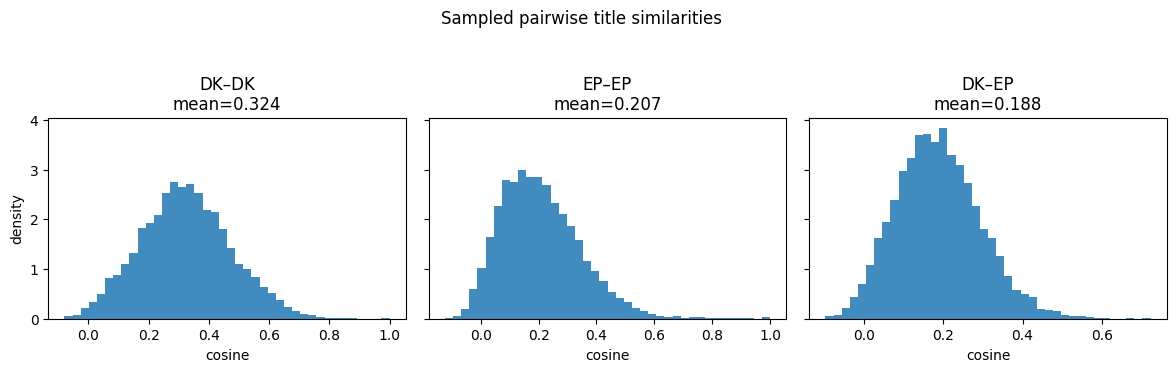

In [49]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(RANDOM_STATE)
N_PAIRS = 10_000

def sample_pair_cosines(a: np.ndarray, b: np.ndarray, n: int, rng) -> np.ndarray:
    i = rng.integers(0, len(a), size=n)
    j = rng.integers(0, len(b), size=n)
    # avoid identical indices for within-corpus samples when same matrix
    if a is b:
        same = i == j
        while same.any():
            j[same] = rng.integers(0, len(b), size=same.sum())
            same = i == j
    return (a[i] * b[j]).sum(axis=1)

cos_dk_dk = sample_pair_cosines(dk_emb, dk_emb, N_PAIRS, rng)
cos_ep_ep = sample_pair_cosines(ep_emb, ep_emb, N_PAIRS, rng)
cos_dk_ep = sample_pair_cosines(dk_emb, ep_emb, N_PAIRS, rng)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, vals, title in zip(
    axes,
    [cos_dk_dk, cos_ep_ep, cos_dk_ep],
    ["DK–DK", "EP–EP", "DK–EP"],
):
    ax.hist(vals, bins=40, density=True, alpha=0.85)
    ax.set_title(f"{title}\nmean={vals.mean():.3f}")
    ax.set_xlabel("cosine")
axes[0].set_ylabel("density")
fig.suptitle("Sampled pairwise title similarities", y=1.05)
plt.tight_layout()
plt.show()

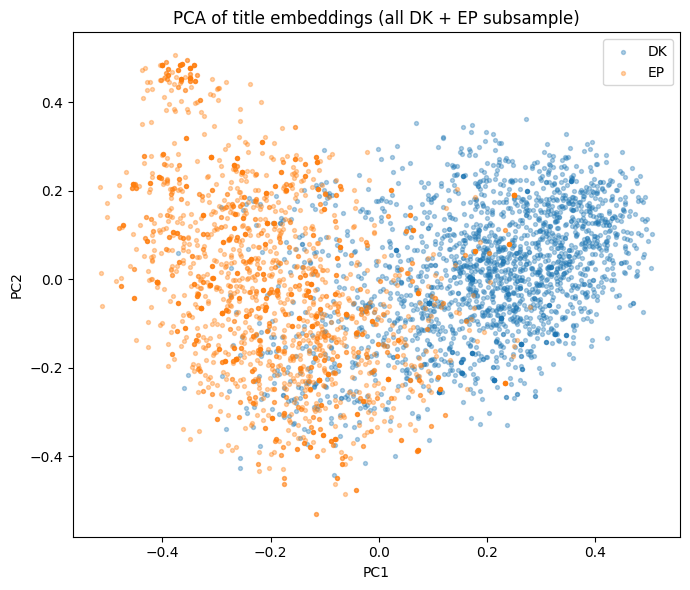

In [50]:
from sklearn.decomposition import PCA

n_dk = len(dk_emb)
ep_sample = rng.choice(len(ep_emb), size=min(n_dk, len(ep_emb)), replace=False)

X = np.vstack([dk_emb, ep_emb[ep_sample]])
labels = np.array(["DK"] * n_dk + ["EP"] * len(ep_sample))

xy = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
for lab, color in [("DK", "C0"), ("EP", "C1")]:
    mask = labels == lab
    ax.scatter(xy[mask, 0], xy[mask, 1], s=8, alpha=0.35, label=lab, c=color)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA of title embeddings (all DK + EP subsample)")
ax.legend()
plt.tight_layout()
plt.show()

c:\Users\kubic\Desktop\machine learning\Customer_satisfaction_prediction\.venv\lib\site-packages\numba\np\ufunc\parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


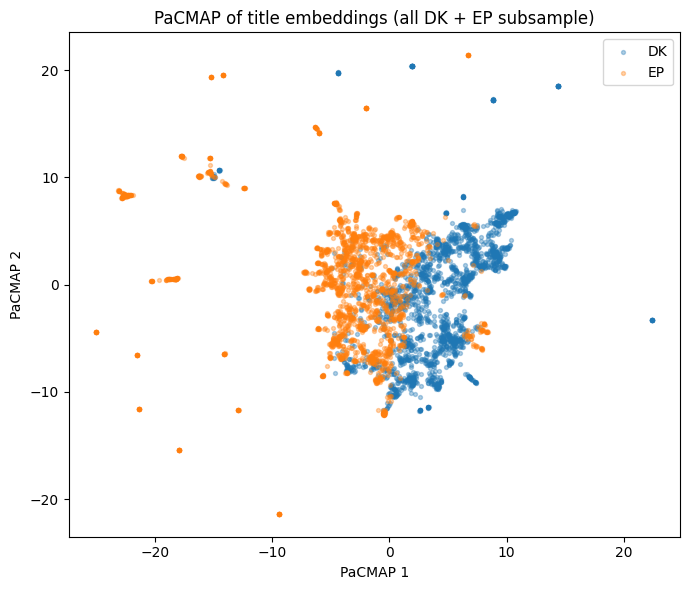

In [51]:
import pacmap

# Reuse the same balanced sample (X, labels) from the PCA cell
reducer = pacmap.PaCMAP(
    n_components=2,
    random_state=RANDOM_STATE,
)
xy_pacmap = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
for lab, color in [("DK", "C0"), ("EP", "C1")]:
    mask = labels == lab
    ax.scatter(
        xy_pacmap[mask, 0],
        xy_pacmap[mask, 1],
        s=8,
        alpha=0.35,
        label=lab,
        c=color,
    )
ax.set_xlabel("PaCMAP 1")
ax.set_ylabel("PaCMAP 2")
ax.set_title("PaCMAP of title embeddings (all DK + EP subsample)")
ax.legend()
plt.tight_layout()
plt.show()

DK → best EP: mean=0.602, median=0.594, p25=0.548, p75=0.650
EP → best DK: mean=0.559, median=0.557, p25=0.496, p75=0.613


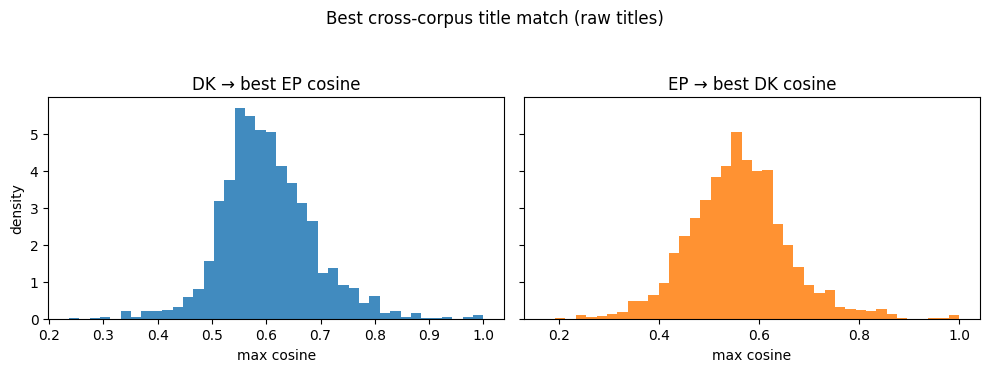


Strongest DK → EP matches:

  1.000
  DK: Draft law on electronic invoicing in public procurement.
  EP: Electronic invoicing in public procurement

  1.000
  DK: Proposal for a law on insurance mediation.
  EP: Insurance mediation

  1.000
  DK: Draft law on payment accounts.
  EP: Payment accounts

  1.000
  DK: Proposal for a law on accessibility requirements for products and services.
  EP: Accessibility requirements for products and services

  0.971
  DK: Proposal for a law on infrastructure for alternative fuels.
  EP: Alternative fuels infrastructure


In [52]:
# Cosine = dot product (embeddings are L2-normalized)
sims_dk_ep = dk_emb @ ep_emb.T  # (n_dk, n_ep)

best_dk_to_ep = sims_dk_ep.max(axis=1)
best_ep_to_dk = sims_dk_ep.max(axis=0)

print(
    "DK → best EP: "
    f"mean={best_dk_to_ep.mean():.3f}, "
    f"median={np.median(best_dk_to_ep):.3f}, "
    f"p25={np.percentile(best_dk_to_ep, 25):.3f}, "
    f"p75={np.percentile(best_dk_to_ep, 75):.3f}"
)
print(
    "EP → best DK: "
    f"mean={best_ep_to_dk.mean():.3f}, "
    f"median={np.median(best_ep_to_dk):.3f}, "
    f"p25={np.percentile(best_ep_to_dk, 25):.3f}, "
    f"p75={np.percentile(best_ep_to_dk, 75):.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].hist(best_dk_to_ep, bins=40, density=True, alpha=0.85, color="C0")
axes[0].set_title("DK → best EP cosine")
axes[0].set_xlabel("max cosine")
axes[0].set_ylabel("density")
axes[1].hist(best_ep_to_dk, bins=40, density=True, alpha=0.85, color="C1")
axes[1].set_title("EP → best DK cosine")
axes[1].set_xlabel("max cosine")
fig.suptitle("Best cross-corpus title match (raw titles)", y=1.05)
plt.tight_layout()
plt.show()

# Show a few strong DK → EP matches
top_qi = np.argsort(-best_dk_to_ep)[:5]
print("\nStrongest DK → EP matches:")
for qi in top_qi:
    ej = int(sims_dk_ep[qi].argmax())
    print(f"\n  {best_dk_to_ep[qi]:.3f}")
    print(f"  DK: {df_dk.loc[qi, 'sag_titel_en'][:140]}")
    print(f"  EP: {df_ep.loc[ej, 'display_title'][:140]}")

In [53]:
# ============================================================
# FIND BEST EP MATCH FOR EVERY DK VOTE
# ============================================================

import numpy as np
import pandas as pd

# Cosine similarity because embeddings are L2-normalized
similarity_matrix = dk_emb @ ep_emb.T

# Best EP match for each DK vote
best_ep_idx = similarity_matrix.argmax(axis=1)
best_ep_similarity = similarity_matrix[
    np.arange(len(dk_emb)),
    best_ep_idx
]


# Build matching dataframe
dk_ep_matches = pd.DataFrame({
    "dk_index": np.arange(len(df_dk)),
    
    "dk_title_original": df_dk["sag_titel_en"].values,
    "dk_title_clean": df_dk["title_clean"].values,
    
    "ep_index": best_ep_idx,
    
    "ep_title_original": df_ep.iloc[best_ep_idx]["display_title"].values,
    "ep_title_clean": df_ep.iloc[best_ep_idx]["title_clean"].values,
    
    "ep_period": df_ep.iloc[best_ep_idx]["period"].values,
    
    "cosine_similarity": best_ep_similarity
})

dk_ep_matches = dk_ep_matches.sort_values(
    "cosine_similarity",
    ascending=False
).reset_index(drop=True)

print("Total DK votes:", len(dk_ep_matches))

display(dk_ep_matches.head(10))

Total DK votes: 2128


,dk_index,dk_title_original,dk_title_clean,ep_index,ep_title_original,ep_title_clean,ep_period,cosine_similarity
0,772,Draft law on electronic invoicing in public procurement.,electronic invoicing in public procurement,6102,Electronic invoicing in public procurement,Electronic invoicing in public procurement,2009-2014,1.000000
1,617,Proposal for a law on insurance mediation.,insurance mediation,5995,Insurance mediation,Insurance mediation,2009-2014,1.000000
2,250,Draft law on payment accounts.,payment accounts,6620,Payment accounts,Payment accounts,2009-2014,1.000000
3,1501,Proposal for a law on accessibility requirements for products and services.,accessibility requirements for products and services,12625,Accessibility requirements for products and services,Accessibility requirements for products and services,2014-2019,1.000000
4,548,Proposal for a law on infrastructure for alternative fuels.,infrastructure for alternative fuels,6615,Alternative fuels infrastructure,Alternative fuels infrastructure,2009-2014,0.971211
5,444,Proposal for a law on the European Union Agency for Law Enforcement Cooperation (Europol).,the European Union Agency for Law Enforcement Cooperation (Europol),5887,European Union Agency for Law Enforcement Cooperation and Training (Europol),European Union Agency for Law Enforcement Cooperation and Training (Europol),2009-2014,0.964785
6,1272,Proposal for a law on products and market surveillance.,products and market surveillance,6770,Market surveillance of products,Market surveillance of products,2009-2014,0.942142
7,266,Proposal for a law on clinical trials of medicinal products.,clinical trials of medicinal products,6422,Clinical trials on medicinal products for human use,Clinical trials on medicinal products for human use,2009-2014,0.933124
8,1898,Proposal for a law supplementing the regulation establishing a carbon border adjustment mechanism.,the regulation establishing a carbon border adjustment mechanism,19242,Carbon Border Adjustment Mechanism: simplification and strengthening,Carbon Border Adjustment Mechanism: simplification and strengthening,2024-2029,0.919171
9,1702,Draft law on credit service companies and credit buyers.,credit service companies and credit buyers,17772,Credit servicers and credit purchasers,Credit servicers and credit purchasers,2019-2024,0.895036


In [54]:
# ============================================================
# SIMILARITY BANDS
# ============================================================

bins = [-np.inf, 0.50, 0.60, 0.70, 0.80, np.inf]

labels = [
    "< 0.50",
    "0.50–0.60",
    "0.60–0.70",
    "0.70–0.80",
    "0.80+"
]

dk_ep_matches["similarity_band"] = pd.cut(
    dk_ep_matches["cosine_similarity"],
    bins=bins,
    labels=labels,
    right=False
)

band_summary = (
    dk_ep_matches["similarity_band"]
    .value_counts(sort=False)
    .rename("n_matches")
    .to_frame()
)

band_summary["percent"] = (
    band_summary["n_matches"]
    / len(dk_ep_matches)
    * 100
).round(1)

display(band_summary)

,n_matches,percent
similarity_band,,
< 0.50,156,7.3
0.50–0.60,971,45.6
0.60–0.70,768,36.1
0.70–0.80,196,9.2
0.80+,37,1.7


In [55]:
# ============================================================
# MATCH QUALITY BY EP PERIOD
# ============================================================

period_summary = (
    dk_ep_matches
    .groupby("ep_period", observed=True)
    .agg(
        n_matches=("cosine_similarity", "size"),
        mean_similarity=("cosine_similarity", "mean"),
        median_similarity=("cosine_similarity", "median"),
        min_similarity=("cosine_similarity", "min"),
        max_similarity=("cosine_similarity", "max")
    )
    .round(3)
)

display(period_summary)

,n_matches,mean_similarity,median_similarity,min_similarity,max_similarity
ep_period,,,,,
2009-2014,830,0.599,0.588,0.286,1.000
2014-2019,653,0.599,0.595,0.236,1.000
2019-2024,562,0.608,0.599,0.351,0.895
2024-2029,83,0.592,0.587,0.339,0.919


In [56]:
# ============================================================
# UNIQUE EP VOTES MATCHED PER PERIOD
# ============================================================

unique_period_summary = (
    dk_ep_matches
    .groupby("ep_period", observed=True)
    .agg(
        matched_dk_votes=("dk_index", "nunique"),
        unique_ep_votes=("ep_index", "nunique")
    )
)

display(unique_period_summary)

,matched_dk_votes,unique_ep_votes
ep_period,,
2009-2014,830,250
2014-2019,653,226
2019-2024,562,175
2024-2029,83,45


The similarity distribution is especially useful:
- 156 (7.3%) are below 0.50
- 971 (45.6%) are 0.50–0.60
- 768 (36.1%) are 0.60–0.70
- 196 (9.2%) are 0.70–0.80
- 37 (1.7%) are ≥0.80
So if, purely hypothetically, we later decided that 0.60 is a reasonable threshold, we'd retain 768 + 196 + 37 = 1,001 DK votes — about 47% of all DK votes. That's potentially a very usable sample. But we should not set 0.60 yet.
The period result is also reassuring. The mean similarities are remarkably stable: 0.599, 0.599, 0.608, and 0.592. So MPNet isn't obviously working well for one EP period and badly for another.
The lower number for 2024–2029 (83 DK matches, 45 unique EP votes) also isn't automatically concerning. That period is still much smaller in your dataset than the completed periods. More importantly, we should eventually compare rates relative to the number of available votes, rather than raw counts alone.

CREATING CSV for manual ANNOTATIONS

In [57]:
# ============================================================
# CREATE CSV FOR MANUAL DK–EP MATCH ANNOTATION
# ============================================================

import pandas as pd

pd.set_option("display.max_colwidth", None)

# Number of examples to sample from each similarity band
N_PER_BAND = 20

bands = [
    "< 0.50",
    "0.50–0.60",
    "0.60–0.70",
    "0.70–0.80",
    "0.80+"
]

annotation_parts = []

for band in bands:

    subset = dk_ep_matches[
        dk_ep_matches["similarity_band"] == band
    ]

    sample = subset.sample(
        n=min(N_PER_BAND, len(subset)),
        random_state=RANDOM_STATE
    )

    annotation_parts.append(sample)


# Combine samples
annotation_df = pd.concat(
    annotation_parts,
    ignore_index=True
)


# Keep useful columns
annotation_df = annotation_df[
    [
        "dk_index",
        "ep_index",
        "ep_period",
        "cosine_similarity",
        "similarity_band",
        "dk_title_original",
        "dk_title_clean",
        "ep_title_original",
        "ep_title_clean"
    ]
].copy()


# ============================================================
# ADD EMPTY MANUAL ANNOTATION COLUMNS
# ============================================================

annotation_df["theme_match"] = ""

annotation_df["notes"] = ""


# ============================================================
# SORT FROM LOWEST TO HIGHEST SIMILARITY
# ============================================================

annotation_df = annotation_df.sort_values(
    "cosine_similarity"
).reset_index(drop=True)


# Give each pair an easy ID
annotation_df.insert(
    0,
    "pair_id",
    range(1, len(annotation_df) + 1)
)


# ============================================================
# SAVE CSV
# ============================================================

ANNOTATION_PATH = (
    CLEAN_OUT_DIR
    / "dk_ep_match_annotation.csv"
)

annotation_df.to_csv(
    ANNOTATION_PATH,
    index=False,
    encoding="utf-8-sig"   # makes Excel handle characters nicely
)


print(f"Saved {len(annotation_df)} pairs.")
print("File:")
print(ANNOTATION_PATH)

display(annotation_df.head(10))

Saved 100 pairs.
File:
..\data\temp_data\embeddings_cleaned\dk_ep_match_annotation.csv


,pair_id,dk_index,ep_index,ep_period,cosine_similarity,similarity_band,dk_title_original,dk_title_clean,ep_title_original,ep_title_clean,theme_match,notes
0,1,1739,12587,2014-2019,0.307871,< 0.50,Proposal for a law amending the law on free community networks. (Extension of selected experimental possibilities etc. in free community experiments II).,the law on free community networks. (Extension of selected experimental possibilities etc. in free community experiments II),Promotion of internet connectivity in local communities,Promotion of internet connectivity in local communities,,
1,2,1893,4245,2009-2014,0.374646,< 0.50,Draft law on flagging.,flagging,"Illegal, unreported and unregulated fishing","Illegal, unreported and unregulated fishing",,
2,3,459,11872,2014-2019,0.392528,< 0.50,Proposal for a law amending the law on equations. (Freedom of movement allowance during basic integration training).,the law on equations. (Freedom of movement allowance during basic integration training),Civil Law Rules on Robotics,Civil Law Rules on Robotics,,
3,4,1490,5360,2009-2014,0.406689,< 0.50,Draft law on the Register of Conductors.,the Register of Conductors,System for registration of carriers of radioactive materials,System for registration of carriers of radioactive materials,,
4,5,1218,17346,2019-2024,0.419124,< 0.50,"Proposal for a law on epidemics, etc. (the epidemic law).","epidemics, etc. (the epidemic law)",The situation in the Schengen area following the COVID19 outbreak,The situation in the Schengen area following the COVID19 outbreak,,
5,6,117,6191,2009-2014,0.426369,< 0.50,Proposal for a law amending the Law on the Use of Force in Psychology.,the Law on the Use of Force in Psychology,Evaluation of justice in relation to criminal justice and the rule of law,Evaluation of justice in relation to criminal justice and the rule of law,,
6,7,581,9123,2014-2019,0.445650,< 0.50,"Draft law amending the law on unemployment insurance, etc. and the law on flexitime benefits (New rules on deductions for voluntary unpaid work for benefit recipients, etc.).","the law on unemployment insurance, etc. and the law on flexitime benefits (New rules on deductions for voluntary unpaid work for benefit recipients, etc.)",Tax rulings and other measures similar in nature or effect,Tax rulings and other measures similar in nature or effect,,
7,8,821,17063,2014-2019,0.451566,< 0.50,Draft law amending the daily offer law. (Better distribution in day-care institutions).,the daily offer law. (Better distribution in day-care institutions),Work-life balance for parents and carers,Work-life balance for parents and carers,,
8,9,2097,4088,2009-2014,0.452528,< 0.50,"Draft law amending the Law on the Council of Congregations, Law on the National Church's Economics, Law on the National Church's Church buildings and cemeteries and various other laws. (Simplification and better support for the church council work, support for the church councils' maintenance of medieval churches and orientation on preliminary equation needs).","the Law on the Council of Congregations, Law on the National Church's Economics, Law on the National Church's Church buildings and cemeteries and various other laws. (Simplification and better support for the church council work, support for the church councils' maintenance of medieval churches and orientation on preliminary equation needs)","Amendment of Regulation (EEC/Euratom) No 354/83, as regards the deposit of the historical archives of the institutions at the European University Institute in Florence","Amendment of Regulation (EEC/Euratom) No 354/83, as regards the deposit of the historical archives of the institutions at the European University Institute in Florence",,
9,10,828,18681,2019-2024,0.453097,< 0.50,Proposal for a law amending the Law on a Cityring and the Law on the Metro Company I/S and the Development Company City & Port I/S. (Developing the area of Ny Ellebjerg Station).,the Law on a Cityring and the Law on the Metro Comp